# Tata Steel - Roller-Table Motor Predictive and Prescriptive Maintenance

**Motor ID:** ROT-MILL-05 | **Process:** TSCR Roller Table | **Sampling Rate:** 1 second

### Pipeline:
1. Full exploratory analysis of key sensor columns
2. Feature engineering with domain-driven metrics
3. Advanced anomaly detection using latest models
4. Model comparison and prescriptive maintenance outputs

**Models used in this notebook:** Rule-based baseline, Isolation Forest, One-Class SVM, LSTM Autoencoder

**Dataset:** `tata_steel_rot_motor_proxy.csv`

## Part 1 - Exploratory Data Analysis

Load the data, inspect structure, and visualize key operational patterns before model building.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import OneClassSVM

warnings.filterwarnings("ignore")

df = pd.read_csv("tata_steel_rot_motor_proxy.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\n--- Data Types & Nulls ---")
df.info()
print("\n--- Descriptive Statistics (numeric) ---")
display(df.describe().round(2))

Shape: (10000, 10)
Columns: ['Timestamp', 'Motor_ID', 'Current_Amp', 'Voltage_V', 'Motor_RPM', 'Vibration_mm_s', 'Winding_Temp_C', 'Bearing_Temp_C', 'Coolant_Pressure_Bar', 'Ambient_Humidity_Pct']

--- Data Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             10000 non-null  str    
 1   Motor_ID              10000 non-null  str    
 2   Current_Amp           10000 non-null  float64
 3   Voltage_V             10000 non-null  float64
 4   Motor_RPM             10000 non-null  float64
 5   Vibration_mm_s        10000 non-null  float64
 6   Winding_Temp_C        10000 non-null  float64
 7   Bearing_Temp_C        10000 non-null  float64
 8   Coolant_Pressure_Bar  10000 non-null  float64
 9   Ambient_Humidity_Pct  10000 non-null  float64
dtypes: float64(8), str(2)
memory usage: 781.4 KB

--- Descriptive

,Current_Amp,Voltage_V,Motor_RPM,Vibration_mm_s,Winding_Temp_C,Bearing_Temp_C,Coolant_Pressure_Bar,Ambient_Humidity_Pct
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,65.01,415.01,1472.50,2.87,72.48,62.53,4.00,74.97
std,20.10,3.03,8.42,1.72,8.39,6.56,0.10,5.05
min,38.88,403.20,1443.80,0.50,59.61,50.88,3.63,54.50
25%,44.99,413.00,1465.00,1.20,64.13,56.75,3.93,71.50
50%,76.69,415.00,1475.80,3.06,72.60,62.59,4.00,75.00
75%,85.01,417.00,1480.00,4.50,80.72,68.25,4.07,78.40
max,93.37,426.50,1487.70,10.34,85.57,74.34,4.38,96.00


### 1.1 Correlation Heatmap - All Numeric Sensors

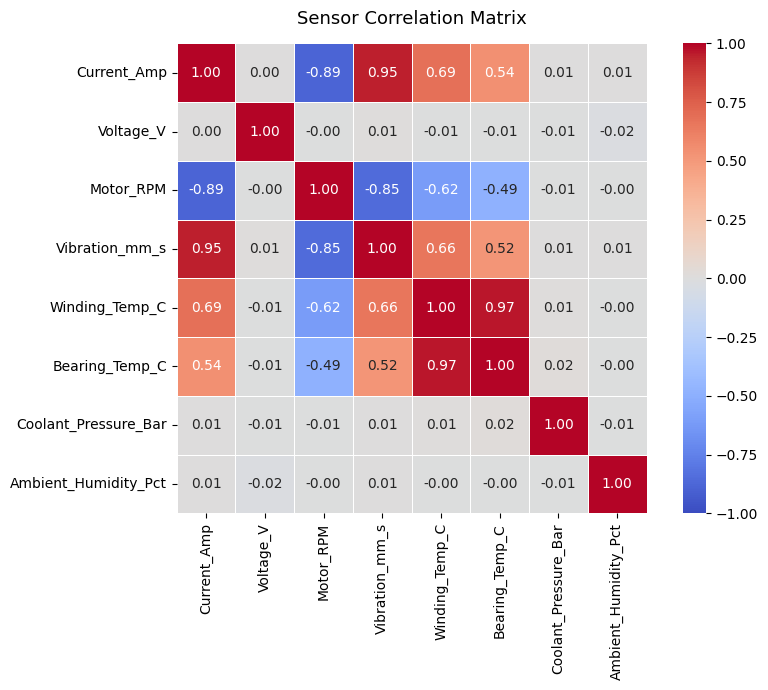

In [2]:
numeric_cols = [
    "Current_Amp", "Voltage_V", "Motor_RPM", "Vibration_mm_s",
    "Winding_Temp_C", "Bearing_Temp_C", "Coolant_Pressure_Bar", "Ambient_Humidity_Pct"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Sensor Correlation Matrix", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

### 1.2 Operational Trend and Lagging Temperature Behavior

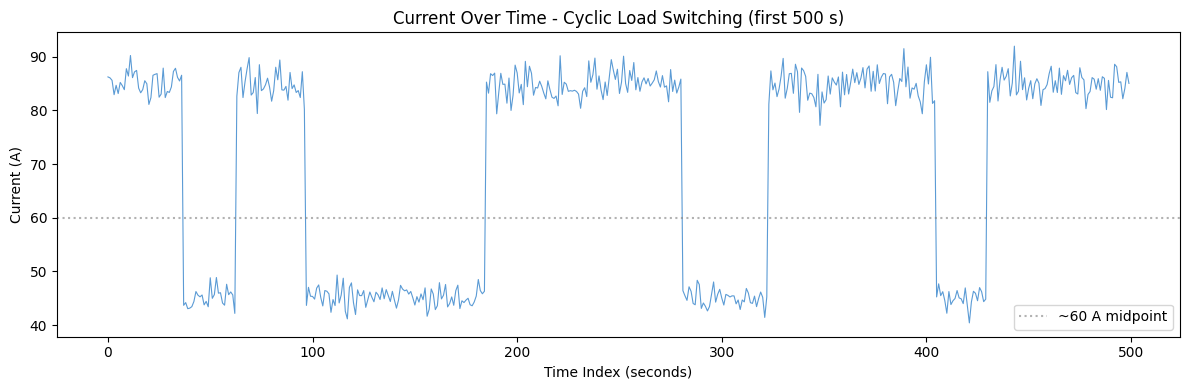

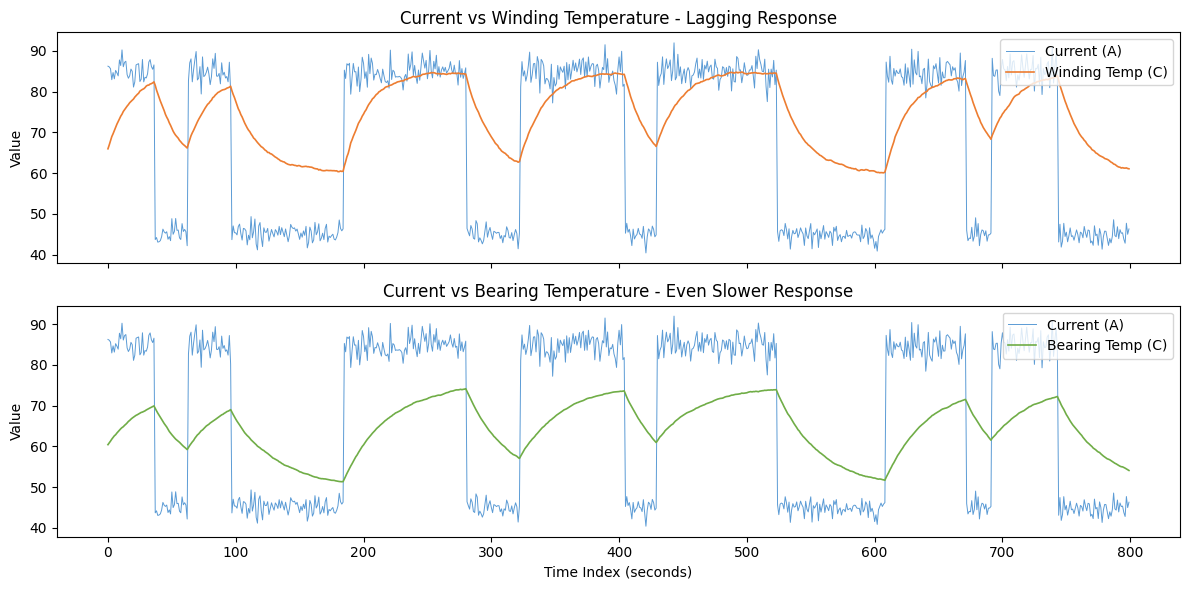

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(df["Current_Amp"].iloc[:500], color="#5B9BD5", linewidth=0.8)
ax.axhline(60, color="gray", linestyle=":", alpha=0.6, label="~60 A midpoint")
ax.set_xlabel("Time Index (seconds)")
ax.set_ylabel("Current (A)")
ax.set_title("Current Over Time - Cyclic Load Switching (first 500 s)")
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = 800

axes[0].plot(df["Current_Amp"].iloc[:t], color="#5B9BD5", linewidth=0.7, label="Current (A)")
axes[0].plot(df["Winding_Temp_C"].iloc[:t], color="#ED7D31", linewidth=1.2, label="Winding Temp (C)")
axes[0].set_ylabel("Value")
axes[0].set_title("Current vs Winding Temperature - Lagging Response")
axes[0].legend(loc="upper right")

axes[1].plot(df["Current_Amp"].iloc[:t], color="#5B9BD5", linewidth=0.7, label="Current (A)")
axes[1].plot(df["Bearing_Temp_C"].iloc[:t], color="#70AD47", linewidth=1.2, label="Bearing Temp (C)")
axes[1].set_xlabel("Time Index (seconds)")
axes[1].set_ylabel("Value")
axes[1].set_title("Current vs Bearing Temperature - Even Slower Response")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 1.3 Rule-Based Baseline (Vibration Spikes)

Rule-based anomalies: 19


,Timestamp,Vibration_mm_s
17,2023-10-01 08:00:17,9.317
324,2023-10-01 08:05:24,8.654
664,2023-10-01 08:11:04,9.035
704,2023-10-01 08:11:44,9.610
1251,2023-10-01 08:20:51,9.921


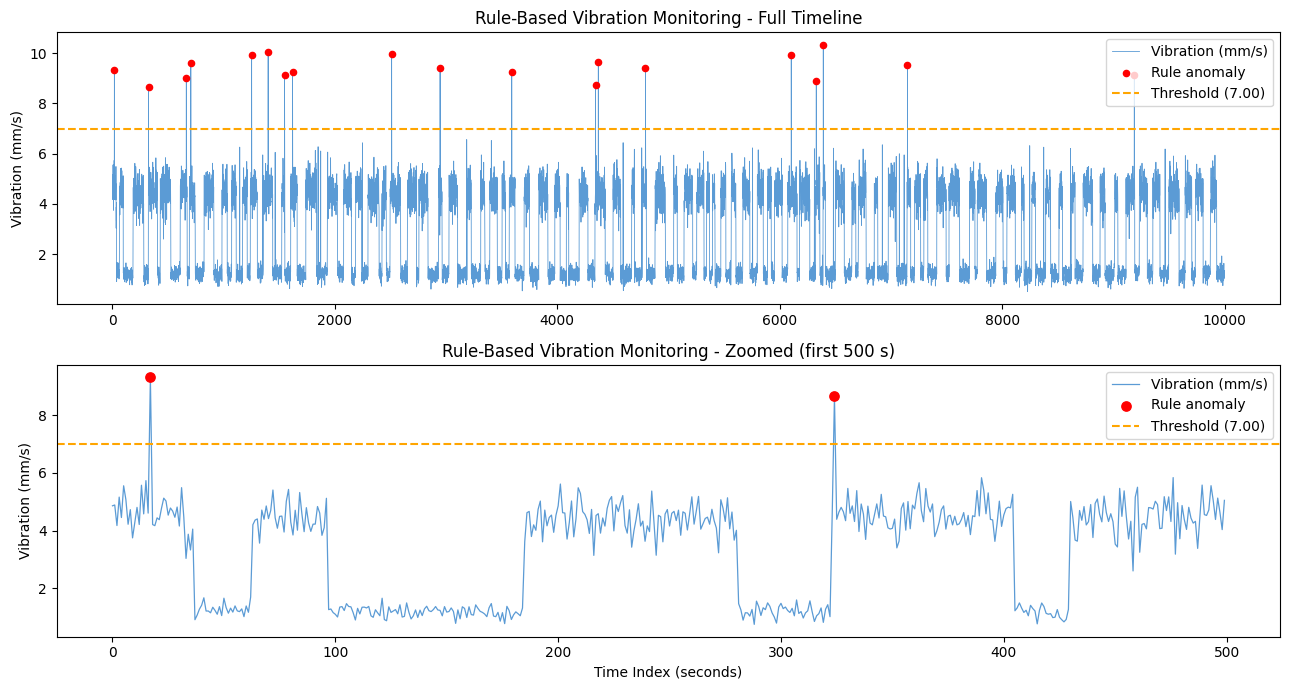

In [4]:
vibration_threshold = 7.0
df["Rule_Anomaly"] = (df["Vibration_mm_s"] > vibration_threshold).astype(int)
anomalies_rule = df[df["Rule_Anomaly"] == 1]

print("Rule-based anomalies:", len(anomalies_rule))
display(anomalies_rule[["Timestamp", "Vibration_mm_s"]].head())

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(df["Vibration_mm_s"], color="#5B9BD5", linewidth=0.6, label="Vibration (mm/s)")
axes[0].scatter(anomalies_rule.index, anomalies_rule["Vibration_mm_s"], color="red", s=20, zorder=5, label="Rule anomaly")
axes[0].axhline(vibration_threshold, color="orange", linestyle="--", label=f"Threshold ({vibration_threshold:.2f})")
axes[0].set_title("Rule-Based Vibration Monitoring - Full Timeline")
axes[0].set_ylabel("Vibration (mm/s)")
axes[0].legend()

z = 500
zoom_rule = anomalies_rule[anomalies_rule.index < z]
axes[1].plot(df["Vibration_mm_s"].iloc[:z], color="#5B9BD5", linewidth=0.9, label="Vibration (mm/s)")
axes[1].scatter(zoom_rule.index, zoom_rule["Vibration_mm_s"], color="red", s=45, zorder=5, label="Rule anomaly")
axes[1].axhline(vibration_threshold, color="orange", linestyle="--", label=f"Threshold ({vibration_threshold:.2f})")
axes[1].set_title(f"Rule-Based Vibration Monitoring - Zoomed (first {z} s)")
axes[1].set_xlabel("Time Index (seconds)")
axes[1].set_ylabel("Vibration (mm/s)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 2 - Feature Engineering for Advanced Models

In [5]:
fe_df = df.copy()

fe_df["Power_Index"] = fe_df["Voltage_V"] * fe_df["Current_Amp"]
fe_df["Current_Deviation"] = fe_df["Current_Amp"] - fe_df["Current_Amp"].rolling(window=30, min_periods=1).mean()

fe_df["Thermal_Gradient"] = fe_df["Winding_Temp_C"] - fe_df["Bearing_Temp_C"]
fe_df["Winding_Temp_Rate"] = fe_df["Winding_Temp_C"].diff().fillna(0)

fe_df["Vibration_RPM_Ratio"] = fe_df["Vibration_mm_s"] / fe_df["Motor_RPM"].clip(lower=1e-6)
fe_df["Vibration_Energy"] = fe_df["Vibration_mm_s"].rolling(window=20, min_periods=1).mean()

fe_df["Cooling_Efficiency"] = fe_df["Coolant_Pressure_Bar"] / fe_df["Winding_Temp_C"].clip(lower=1e-6)
fe_df["Humidity_Thermal_Stress"] = fe_df["Ambient_Humidity_Pct"] * fe_df["Winding_Temp_C"]

print("Engineered features ready.")
display(fe_df[[
    "Power_Index", "Current_Deviation", "Thermal_Gradient", "Winding_Temp_Rate",
    "Vibration_RPM_Ratio", "Vibration_Energy", "Cooling_Efficiency", "Humidity_Thermal_Stress"
]].head())

Engineered features ready.


,Power_Index,Current_Deviation,Thermal_Gradient,Winding_Temp_Rate,Vibration_RPM_Ratio,Vibration_Energy,Cooling_Efficiency,Humidity_Thermal_Stress
0,35841.030,0.000000,5.54,0.00,0.003320,4.85800,0.062149,4888.377
1,35705.984,-0.090000,6.06,0.94,0.003335,4.87200,0.057391,4770.683
2,35318.250,-0.366667,6.65,1.04,0.002832,4.63900,0.058278,5639.850
3,34747.755,-2.277500,7.18,1.01,0.003534,4.76925,0.056700,4654.800
4,35120.943,-0.430000,7.48,0.70,0.003051,4.70560,0.057565,6150.978


## Part 3 - Advanced Anomaly Detection Models

This section uses only the latest model stack: Isolation Forest, One-Class SVM, and LSTM Autoencoder.

### 3.1 Model 1 - Isolation Forest

Isolation Forest anomalies: 100 (1.00% of rows)


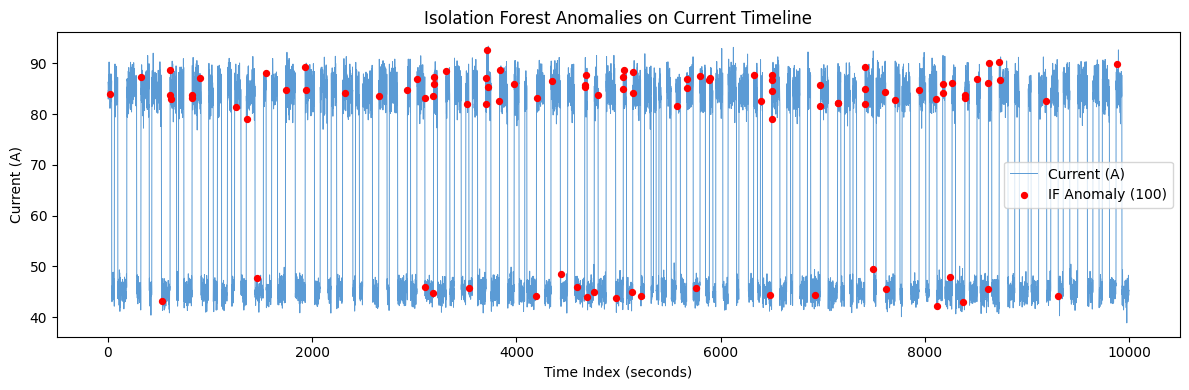

In [6]:
if_features = ["Motor_RPM", "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C", "Voltage_V"]
X_if = fe_df[if_features]

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

df["IF_Anomaly"] = iso_forest.fit_predict(X_if)
if_anomalies = df[df["IF_Anomaly"] == -1]

print(f"Isolation Forest anomalies: {len(if_anomalies)} ({100*len(if_anomalies)/len(df):.2f}% of rows)")

plt.figure(figsize=(12, 4))
plt.plot(df["Current_Amp"], color="#5B9BD5", linewidth=0.7, label="Current (A)")
plt.scatter(if_anomalies.index, if_anomalies["Current_Amp"], color="red", s=18, zorder=5, label=f"IF Anomaly ({len(if_anomalies)})")
plt.title("Isolation Forest Anomalies on Current Timeline")
plt.xlabel("Time Index (seconds)")
plt.ylabel("Current (A)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Model 2 - One-Class SVM

In [7]:
svm_features = ["Motor_RPM", "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C", "Voltage_V"]

clean_idle_mask = (
    (df["Current_Amp"] < 60)
    & (df["Vibration_mm_s"] < vibration_threshold)
)

X_svm_all = df[svm_features]
X_svm_train = df.loc[clean_idle_mask, svm_features]
print(f"One-Class SVM training rows: {len(X_svm_train)} ({100*len(X_svm_train)/len(df):.1f}% of dataset)")

svm_scaler = StandardScaler()
X_svm_train_scaled = svm_scaler.fit_transform(X_svm_train)
X_svm_all_scaled = svm_scaler.transform(X_svm_all)

oc_svm = OneClassSVM(kernel="rbf", nu=0.005)
oc_svm.fit(X_svm_train_scaled)

df["OCSVM_Anomaly"] = oc_svm.predict(X_svm_all_scaled)
ocsvm_anomalies = df[df["OCSVM_Anomaly"] == -1]

print(f"One-Class SVM anomalies: {len(ocsvm_anomalies)} ({100*len(ocsvm_anomalies)/len(df):.2f}% of rows)")

One-Class SVM training rows: 4999 (50.0% of dataset)
One-Class SVM anomalies: 5039 (50.39% of rows)


### 3.3 Model 3 - LSTM Autoencoder

In [8]:
try:
    import importlib

    tf = importlib.import_module("tensorflow")
    keras = tf.keras
    layers = keras.layers

    tf.random.set_seed(42)

    lstm_features = ["Current_Amp", "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C", "Motor_RPM"]
    lstm_data = df[lstm_features].values.astype("float32")

    lstm_scaler = MinMaxScaler()
    lstm_data_scaled = lstm_scaler.fit_transform(lstm_data)

    WINDOW = 30
    N_FEAT = len(lstm_features)

    def make_sequences(arr, window):
        return np.array([arr[i:i + window] for i in range(len(arr) - window)])

    sequences = make_sequences(lstm_data_scaled, WINDOW)
    split_idx = int(0.70 * len(sequences))
    X_lstm_train = sequences[:split_idx]
    X_lstm_all = sequences

    inputs = keras.Input(shape=(WINDOW, N_FEAT))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.RepeatVector(WINDOW)(x)
    x = layers.LSTM(32, return_sequences=True)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(N_FEAT))(x)

    autoencoder = keras.Model(inputs, outputs, name="LSTM_Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mae")

    history = autoencoder.fit(
        X_lstm_train,
        X_lstm_train,
        epochs=8,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    X_pred_all = autoencoder.predict(X_lstm_all, verbose=0)
    recon_error_all = np.mean(np.abs(X_lstm_all - X_pred_all), axis=(1, 2))

    X_pred_train = autoencoder.predict(X_lstm_train, verbose=0)
    recon_error_train = np.mean(np.abs(X_lstm_train - X_pred_train), axis=(1, 2))

    lstm_thresh = recon_error_train.mean() + 3 * recon_error_train.std()

    lstm_anomaly_flag = np.zeros(len(df), dtype=int)
    window_flags = (recon_error_all > lstm_thresh).astype(int)
    for w_idx, f in enumerate(window_flags):
        if f == 1:
            lstm_anomaly_flag[w_idx:w_idx + WINDOW] = 1

    df["LSTM_Anomaly"] = lstm_anomaly_flag

    print(f"LSTM threshold: {lstm_thresh:.6f}")
    print(f"LSTM anomalies: {int(df['LSTM_Anomaly'].sum())} ({100*df['LSTM_Anomaly'].mean():.2f}% of rows)")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(recon_error_all, color="#1f77b4", linewidth=0.9, label="Reconstruction error")
    axes[0].axhline(lstm_thresh, color="red", linestyle="--", label=f"Threshold ({lstm_thresh:.5f})")
    axes[0].set_title("LSTM Reconstruction Error")
    axes[0].set_xlabel("Window index")
    axes[0].set_ylabel("MAE")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train loss")
    axes[1].plot(history.history["val_loss"], label="Val loss")
    axes[1].set_title("LSTM Training History")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss (MAE)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

except Exception:
    print("Skipping LSTM Autoencoder - TensorFlow unavailable.")
    df["LSTM_Anomaly"] = 0

Skipping LSTM Autoencoder - TensorFlow unavailable.


## Part 4 - Model Comparison and Prescriptive Output

=== Anomaly Detection Model Comparison ===


,Model,Anomalies Detected,Percent of Rows,Vibration Spike Coverage (%),Method Type
0,Rule-Based,19,0.19,100.00,Threshold
1,Isolation Forest,100,1.00,42.11,Tree ensemble
2,One-Class SVM,5039,50.39,100.00,Kernel boundary
3,LSTM Autoencoder,0,0.00,0.00,Deep reconstruction


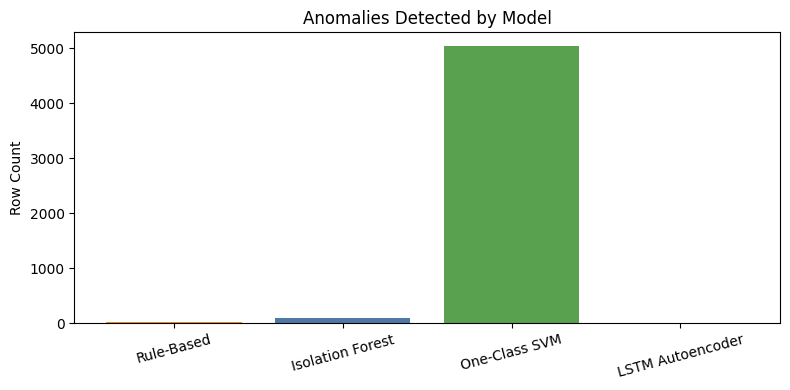

In [9]:
spike_mask = df["Vibration_mm_s"] > vibration_threshold
n_spikes = int(spike_mask.sum())

rule_idx = df[df["Rule_Anomaly"] == 1].index
if_idx = df[df["IF_Anomaly"] == -1].index
oc_idx = df[df["OCSVM_Anomaly"] == -1].index
lstm_idx = df[df["LSTM_Anomaly"] == 1].index

def spike_coverage(anom_idx):
    if n_spikes == 0:
        return 0.0
    return 100.0 * spike_mask.loc[anom_idx].sum() / n_spikes

comparison_df = pd.DataFrame({
    "Model": ["Rule-Based", "Isolation Forest", "One-Class SVM", "LSTM Autoencoder"],
    "Anomalies Detected": [len(rule_idx), len(if_idx), len(oc_idx), len(lstm_idx)],
    "Percent of Rows": [
        round(100 * len(rule_idx) / len(df), 3),
        round(100 * len(if_idx) / len(df), 3),
        round(100 * len(oc_idx) / len(df), 3),
        round(100 * len(lstm_idx) / len(df), 3),
    ],
    "Vibration Spike Coverage (%)": [
        round(spike_coverage(rule_idx), 2),
        round(spike_coverage(if_idx), 2),
        round(spike_coverage(oc_idx), 2),
        round(spike_coverage(lstm_idx), 2),
    ],
    "Method Type": [
        "Threshold",
        "Tree ensemble",
        "Kernel boundary",
        "Deep reconstruction",
    ]
})

print("=== Anomaly Detection Model Comparison ===")
display(comparison_df)

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Model"], comparison_df["Anomalies Detected"], color=["#f28e2b", "#4e79a7", "#59a14f", "#e15759"])
plt.xticks(rotation=15)
plt.title("Anomalies Detected by Model")
plt.ylabel("Row Count")
plt.tight_layout()
plt.show()

In [10]:
# Attach anomaly outputs to engineered frame for prescriptive logic
fe_df["IF_Anomaly"] = df["IF_Anomaly"]
fe_df["OCSVM_Anomaly"] = df["OCSVM_Anomaly"]
fe_df["LSTM_Anomaly"] = df["LSTM_Anomaly"]

power_index_95 = fe_df["Power_Index"].quantile(0.95)

def prescriptive_engineering_rules(row):
    actions = []

    if row["Vibration_Energy"] > 4:
        actions.append("Inspect bearings and lubrication")
    if row["Vibration_RPM_Ratio"] > 0.004:
        actions.append("Check shaft alignment")
    if row["Thermal_Gradient"] > 20:
        actions.append("Inspect insulation and heat dissipation")
    if row["Winding_Temp_Rate"] > 0.5:
        actions.append("Reduce load or enhance cooling")
    if row["Cooling_Efficiency"] < 0.03:
        actions.append("Inspect coolant flow and pressure")
    if row["Humidity_Thermal_Stress"] > 6000:
        actions.append("Improve ventilation and moisture control")
    if row["Current_Deviation"] > 10:
        actions.append("Inspect mechanical load fluctuation")
    if row["Power_Index"] > power_index_95:
        actions.append("Verify supply voltage and motor loading")

    model_vote = int(row["IF_Anomaly"] == -1) + int(row["OCSVM_Anomaly"] == -1) + int(row["LSTM_Anomaly"] == 1)
    if model_vote >= 2:
        actions.append("Escalate: multi-model anomaly confirmation")

    return ", \
Normal operation"

fe_df["Prescriptive_Action"] = fe_df.apply(prescriptive_engineering_rules, axis=1)
print("Top prescriptive actions:")
display(fe_df["Prescriptive_Action"].value_counts().head(10))

Top prescriptive actions:


Prescriptive_Action
, Normal operation    10000
Name: count, dtype: int64

In [11]:
final_cols = [
    "Timestamp",
    "Motor_ID",
    "Current_Amp",
    "Motor_RPM",
    "Vibration_mm_s",
    "Winding_Temp_C",
    "Bearing_Temp_C",
    "Thermal_Gradient",
    "Vibration_Energy",
    "Cooling_Efficiency",
    "Rule_Anomaly",
    "IF_Anomaly",
    "OCSVM_Anomaly",
    "LSTM_Anomaly",
    "Prescriptive_Action",
]

display(fe_df[final_cols].head(15))

,Timestamp,Motor_ID,Current_Amp,Motor_RPM,Vibration_mm_s,Winding_Temp_C,Bearing_Temp_C,Thermal_Gradient,Vibration_Energy,Cooling_Efficiency,Rule_Anomaly,IF_Anomaly,OCSVM_Anomaly,LSTM_Anomaly,Prescriptive_Action
0,2023-10-01 08:00:00,ROT-MILL-05,86.26,1463.4,4.858,65.97,60.43,5.54,4.858000,0.062149,0,1,-1,0,", Normal operation"
1,2023-10-01 08:00:01,ROT-MILL-05,86.08,1465.1,4.886,66.91,60.85,6.06,4.872000,0.057391,0,1,-1,0,", Normal operation"
2,2023-10-01 08:00:02,ROT-MILL-05,85.62,1473.6,4.173,67.95,61.30,6.65,4.639000,0.058278,0,1,-1,0,", Normal operation"
3,2023-10-01 08:00:03,ROT-MILL-05,82.95,1460.0,5.160,68.96,61.78,7.18,4.769250,0.056700,0,1,-1,0,", Normal operation"
4,2023-10-01 08:00:04,ROT-MILL-05,84.69,1458.7,4.451,69.66,62.18,7.48,4.705600,0.057565,0,1,-1,0,", Normal operation"
5,2023-10-01 08:00:05,ROT-MILL-05,83.16,1464.3,5.553,70.46,62.60,7.86,4.846833,0.058189,0,1,-1,0,", Normal operation"
6,2023-10-01 08:00:06,ROT-MILL-05,85.23,1472.4,5.076,71.23,62.87,8.36,4.879571,0.056297,0,1,-1,0,", Normal operation"
7,2023-10-01 08:00:07,ROT-MILL-05,84.64,1464.5,4.217,72.01,63.28,8.73,4.796750,0.058881,0,1,-1,0,", Normal operation"
8,2023-10-01 08:00:08,ROT-MILL-05,83.88,1470.4,4.724,72.64,63.63,9.01,4.788667,0.054102,0,1,-1,0,", Normal operation"
9,2023-10-01 08:00:09,ROT-MILL-05,87.79,1464.6,3.744,73.31,64.00,9.31,4.684200,0.055927,0,1,-1,0,", Normal operation"
